In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
start_year = 2004
end_year = 2014
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_drug_reaction_associations.csv'

In [ ]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['patient_sex']=='All']
preds = preds.dropna()
preds.head()

,drug,reaction,sex,replicate,a,b,c,d,OR,PRR,PHI,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI,mean,prr_diff
0,amoxicillin,cardio-respiratory arrest,All,0,18,12062,24,19398,1.206143,1.205836,0.003389,39.0,21483.0,5200.0,4963497.0,1.732823,1.731495,0.001549,0.001490,-0.361812
1,amoxicillin,inguinal hernia,All,0,6,12074,5,19417,1.929800,1.929338,0.006226,13.0,21509.0,835.0,4967862.0,3.595888,3.594320,0.002192,0.000497,-0.622178
2,amoxicillin,diarrhoea haemorrhagic,All,0,23,12057,14,19408,2.644486,2.641355,0.016796,33.0,21489.0,1751.0,4966946.0,4.356132,4.350986,0.004094,0.001904,-0.499110
3,amoxicillin,blood creatine phosphokinase increased,All,0,44,12036,35,19387,2.024944,2.021211,0.017891,81.0,21441.0,11042.0,4957655.0,1.696167,1.693547,0.002142,0.003642,0.176872
4,amoxicillin,injection site pain,All,0,34,12046,192,19230,0.282692,0.284711,-0.040739,41.0,21481.0,35493.0,4933204.0,0.265287,0.266687,-0.004082,0.002815,0.065402


In [8]:
# negative controls
negative_files = [f for f in os.listdir(f'../results/{start_year}-{end_year}') if f.endswith(f"confounded_examples.csv")]
negative_df = None
for fn in negative_files:
    df = pd.read_csv(os.path.join('../', 'results', f'{start_year}-{end_year}', fn))
    if negative_df is None:
        negative_df = df
    else:
        negative_df = pd.concat([negative_df, df])

negative_df['reaction'] = negative_df['reaction'].str.lower()
negative_df['label'] = 0
negative_df.head()

,Unnamed: 0,indication,reaction,drug,PHI_conf_drug,PRR_drug_rea,conf_drug,sex,age,label
0,0,5Q MINUS MDS,myelodysplastic syndrome,azacitidine,0.004333,109.253364,NaN,NaN,NaN,0
1,1,5Q MINUS MDS,myelodysplastic syndrome,lenalidomide,0.017928,27.267165,NaN,NaN,NaN,0
2,2,5Q MINUS SYNDROME,acute myeloid leukaemia,azacitidine,0.009389,219.019066,NaN,NaN,NaN,0
3,3,5Q MINUS SYNDROME,cytogenetic abnormality,azacitidine,0.009389,36.172487,NaN,NaN,NaN,0
4,4,5Q MINUS SYNDROME,full blood count decreased,azacitidine,0.009389,11.271460,NaN,NaN,NaN,0


In [9]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [10]:
reference = pd.concat([positive_df[['drug', 'reaction', 'label']], negative_df[['drug', 'reaction', 'label']]])
reference.tail()

,drug,reaction,label
2198,zolpidem,sexual assault victim,0
2199,zonisamide,atonic seizures,0
2200,zonisamide,impulsive behaviour,0
2201,zonisamide,myoclonic epilepsy,0
2202,zonisamide,ovarian granulosa-theca cell tumour,0


In [11]:
pred_drugs = set(preds.drug.unique())
ref_drugs = set(reference.drug.unique())
len(pred_drugs), len(ref_drugs), len(pred_drugs&ref_drugs)

(1160, 1554, 1147)

In [12]:
pred_reactions = set(preds.reaction.unique())
ref_reactions = set(reference.reaction.unique())
len(pred_reactions), len(ref_reactions), len(pred_reactions&ref_reactions)

(6113, 8447, 6066)

In [17]:
rep = 1
merged = pd.merge(preds, reference, on=['drug', 'reaction'], how='inner')
merged = merged[merged['replicate']==rep]
merged.label.sum(), len(merged.label)

(18797, 2757338)

0.71678667348589
0.014074263241985718


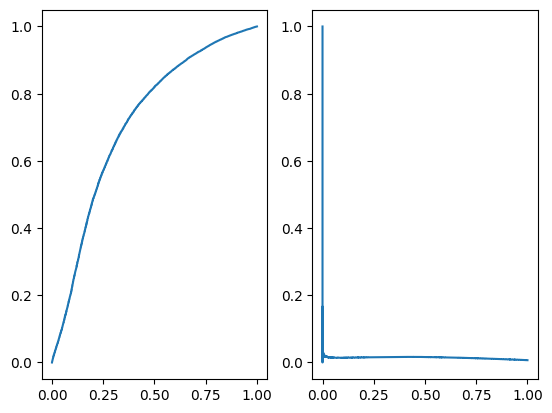

In [18]:
col = 'prr_diff'

print(metrics.roc_auc_score(merged['label'], merged[col]))
print(metrics.average_precision_score(merged['label'], merged[col]))
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr)

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr)


In [19]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
neg.mean(), pos.mean()

(-1.1105756049331708, -0.4227459403917998)